In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy
import copy

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time 
import matplotlib as mpl

from pyiga import assemble, bspline, vform, geometry, vis, solvers, utils, topology, ieti, algebra, operators, adaptive, approx
from pyiga import algebra_cy, ieti_cy, bspline_cy

from scipy.sparse.linalg import aslinearoperator as LinOp

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

In [2]:
def draw_loglog_slope(fig, ax, origin, width_inches, slope, inverted=False, color=None, polygon_kwargs=None, label=True, labelcolor=None, label_kwargs=None, zorder=None):
    """
    This function draws slopes or "convergence triangles" into loglog plots.
    @param fig: The figure
    @param ax: The axes object to draw to
    @param origin: The 2D origin (usually lower-left corner) coordinate of the triangle
    @param width_inches: The width in inches of the triangle
    @param slope: The slope of the triangle, i.e. order of convergence
    @param inverted: Whether to mirror the triangle around the origin, i.e. whether 
        it indicates the slope towards the lower left instead of upper right (defaults to false)
    @param color: The color of the of the triangle edges (defaults to default color)
    @param polygon_kwargs: Additional kwargs to the Polygon draw call that creates the slope
    @param label: Whether to enable labeling the slope (defaults to true)
    @param labelcolor: The color of the slope labels (defaults to the edge color)
    @param label_kwargs: Additional kwargs to the Annotation draw call that creates the labels
    @param zorder: The z-order value of the triangle and labels, defaults to a high value
    """

    if polygon_kwargs is None:
        polygon_kwargs = {}
    if label_kwargs is None:
        label_kwargs = {}

    if color is not None:
        polygon_kwargs["color"] = color
    if "linewidth" not in polygon_kwargs:
        polygon_kwargs["linewidth"] = 0.75 * mpl.rcParams["lines.linewidth"]
    if labelcolor is not None:
        label_kwargs["color"] = labelcolor
    if "color" not in label_kwargs:
        label_kwargs["color"] = polygon_kwargs["color"]
    if "fontsize" not in label_kwargs:
        label_kwargs["fontsize"] = 0.75 * mpl.rcParams["font.size"]

    if inverted:
        width_inches = -width_inches
    if zorder is None:
        zorder = 10

    # For more information on coordinate transformations in Matplotlib see
    # https://matplotlib.org/3.1.1/tutorials/advanced/transforms_tutorial.html

    # Convert the origin into figure coordinates in inches
    origin_disp = ax.transData.transform(origin)
    origin_dpi = fig.dpi_scale_trans.inverted().transform(origin_disp)

    # Obtain the top-right corner in data coordinates
    corner_dpi = origin_dpi + width_inches * np.array([1.0, 0.0])
    corner_disp = fig.dpi_scale_trans.transform(corner_dpi)
    corner = ax.transData.inverted().transform(corner_disp)

    (x1, y1) = (origin[0], origin[1])
    x2 = corner[0]

    # The width of the triangle in data coordinates
    width = x2 - x1
    # Compute offset of the slope
    log_offset = y1 / (x1 ** (-slope))

    y2 = log_offset * (x2 ** (-slope))
    height = y2 - y1

    # The vertices of the slope
    a = origin
    b = corner
    c = [x2, y2]

    # Draw the slope triangle
    X = np.array([a, b, c])
    triangle = plt.Polygon(X[:3,:], fill=False, zorder=zorder, **polygon_kwargs)
    ax.add_patch(triangle)

    # Convert vertices into display space
    a_disp = ax.transData.transform(a)
    b_disp = ax.transData.transform(b)
    c_disp = ax.transData.transform(c)

    # Figure out the center of the triangle sides in display space
    bottom_center_disp = a_disp + 0.5 * (b_disp - a_disp)
    bottom_center = ax.transData.inverted().transform(bottom_center_disp)

    right_center_disp = b_disp + 0.5 * (c_disp - b_disp)
    right_center = ax.transData.inverted().transform(right_center_disp)

    # Label alignment depending on inversion parameter
    va_xlabel = "bottom" if not inverted else "top"
    ha_ylabel = "left" if not inverted else "right"

    # Label offset depending on inversion parameter
    offset_xlabel = [0.0, 0.33 * label_kwargs["fontsize"]] if not inverted else [0.0, -0.33 * label_kwargs["fontsize"]]
    offset_ylabel = [0.33 * label_kwargs["fontsize"], 0.0] if not inverted else [-0.33 * label_kwargs["fontsize"], 0.0]

    # Draw the slope labels
    #ax.annotate("$1$", bottom_center, xytext=offset_xlabel, textcoords='offset points', ha="center", va=va_xlabel, zorder=zorder, **label_kwargs)
    ax.annotate(f"${slope}$", right_center, xytext=offset_ylabel, textcoords='offset points', ha=ha_ylabel, va="center", zorder=zorder, **label_kwargs)


In [3]:
def Lshape(deg, N, k=1):
    kvs = [2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),),2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.Quad(np.array([[-1,-1],[0,-1],[-1,1],[0,0]]).T),
        geometry.Quad(np.array([[-1,1],[0,0],[1,1],[1,0]]).T)
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    return M

In [4]:
def LshapeAnnulus(deg, N, k=1):
    kvs = 3*[2 * (bspline.make_knots(deg, 0.0, 1.0, N, mult=k),)]

    # define geometry
    geos = [
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4),
        geometry.annulus(r1=1.5, r2=2, phi = np.pi/4).rotate_2d(angle=np.pi/4),
        geometry.annulus(r1=1.0, r2=1.5, phi = np.pi/4).rotate_2d(angle=np.pi/4),
    ]

    patches = [(k, g) for k, g in zip(kvs,geos)]
    M = topology.MultiPatch(patches)
    M.outer_boundaries[0].add((1,(0,0)))
    return M

In [5]:
def cart2pol(x, y):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(r, phi%(2*np.pi))
def u_exact(x,y):
    r, phi = cart2pol(x,y)
    return r**(2/3)*np.sin(2*phi/3)
def grad_u(x,y):
    r, phi = cart2pol(x,y)
    return (-2./3*r**(-1./3)*np.sin(phi/3),
             2./3*r**(-1./3)*np.cos(phi/3))

In [12]:
example=1
if example==0:
    f = 0
    dir_data = {0:u_exact}
    exact = True
elif example==1:
    f = 1
    dir_data = {0:0}
    exact = False

degs = (5,)
maxpatches =(7000,)
maxiter=(23,)
#maxdofs = (1e5,)
#maxiter=4*(50,)
eps=(1e-10,)
plot=1
uniform=0

R = np.zeros((max(maxiter),len(degs)*7))

for i,deg in enumerate(degs):
    print("#########################################")
    N = deg+1
    if example==0:
        M = Lshape(deg,N,1)
    elif example==1:
        M = LshapeAnnulus(deg,N,1)

    MB = assemble.MultiBasis(M, subspace='C0')
    eta=1.0
    U=[]
    k=0
    while k<maxiter[i]:
        B = (MB.B@MB.R_related.T).tocsr()
        t1 =time.time()
        Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
        R[k,i*7+5]= time.time()-t1
        Basis = scipy.sparse.hstack([MB.R_free.T, MB.R_related.T@Basis], format='csc')
        R[k,i*7+6]=time.time()-t1
        
        print(k)
        if plot:
            M.plotmesh(figsize=(10,10), knots=1, nodes=50, bwidth=0.01, patch_idx=0)
            plt.axis('off');
            plt.axis('scaled');
            #plt.savefig('/home/wolfman/Pictures/p'+str(deg)+'i'+str(k)+'.png',dpi=100,bbox_inches='tight');
            if example==0:
                if uniform:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                else:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/Lshape/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            elif example==1:
                if uniform:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'_uniform.png', bbox_inches='tight',dpi=100)
                else:
                    plt.savefig('/mnt/c/Users/stefa/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
                    #plt.savefig('/home/wolfman/Pictures/LshapeQ/p'+str(deg)+'/i'+str(k)+'.png', bbox_inches='tight',dpi=100)
            #plt.show();
            plt.close();
            
        ### SOLVE
        R[k,i*7] = MB.nDofs
        R[k,i*7+1] = MB.nPatches

        dir_bcs = MB.set_fixed_boundary(dir_data, local=False)

        Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)

        #uh = LS.complete(pypardiso.spsolve(LS.A,LS.b))
        uh = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        U.append(uh)
        if exact:
            # Mh = MB.assemble_volume("u * v * dx", arity=2, domain_id=0)
            # Uh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=u_exact)
            # Pu = operators.make_solver(Mh,spd=True)@Uh

            Eerr = MB.H1err(u_exact,grad_u,MB.function(uh))
            # eh = Pu-uh
            # Eerr2 = np.sqrt(eh@Kh@eh)

            R[k,i*7+2] = Eerr
            
        # MB.plot(uh, mesh=True)
        # plt.show();

        if not uniform:
            err_ind=adaptive.mp_resPois(MB, uh, nu=1, f=f)
            eta = np.linalg.norm(err_ind)
            R[k,i*5+3] = eta
            marked_patches = adaptive.doerfler_mark(err_ind, theta=0.8, TOL=0.01)
            marked_patches = {p:None for p in marked_patches}

            if not uniform and exact:
                R[k,i*7+4] = eta/Eerr

        # print(Eerr)
        #print(Eerr, Eerr2)
        # print(eta/Eerr)

        if not uniform:
            if MB.nPatches + 3*len(marked_patches) >= maxpatches[i]:
                break;

        if eta < eps[i]:
            break;

        if k<maxiter[i]-1:
            if not uniform:
                P = MB.h_refine(h_ref=marked_patches,ref="rs", return_P = not exact, in_subspace=True)
            else:
                P = MB.h_refine(h_ref=-1,ref="rs", return_P = not exact, in_subspace=True)

        # if not exact:
        #     for j in range(len(U)):
        #         U[j]=P@U[j]
        k+=1
    #if not exact:
        # P = MB.h_refine(h_ref=-1,ref="rs", return_P = True, in_subspace=True)
        # P = MB.p_refine(1, return_P = True, in_subspace=True)@P

        # dir_bcs = MB.set_fixed_boundary(dir_data, local=False)
        # Kh = MB.assemble_volume("inner(grad(u),grad(v)) * dx", arity=2, domain_id=0)
        # Fh = MB.assemble_volume("(f * v) * dx", arity=1, domain_id=0, f=f)
        # LS = assemble.RestrictedLinearSystem(Kh, Fh, dir_bcs)
        
        # u_exact = LS.complete(solvers.make_solver(LS.A, spd=True)@LS.b)

        # for j in range(len(U)):
        #     eh = u_exact - P@U[j]
        #     Eerr = np.sqrt(eh@Kh@eh)
        #     R[j,i*7+2] = Eerr
        #     R[j,i*7+4] = R[j,i*5+3]/Eerr
        
    # if example==0:
    #     if uniform:
    #         np.save('Lshape_uniform_p'+str(deg),R)
    #     else:
    #         np.save('Lshape_adaptive_p'+str(deg),R)
    # elif example==1:
    #     if uniform:
    #         np.save('LshapeQ_uniform_p'+str(deg),R)
    #     else:
    #         np.save('LshapeQ_adaptive_p'+str(deg),R)

#########################################
setting up constraints took 0.0016181468963623047 seconds.
Basis setup took 0.0011432170867919922 seconds
0
setting up constraints took 0.013169527053833008 seconds.
Basis setup took 0.0019102096557617188 seconds
1
setting up constraints took 0.0333709716796875 seconds.
Basis setup took 0.001569509506225586 seconds
2
setting up constraints took 0.037912845611572266 seconds.
Basis setup took 0.0017316341400146484 seconds
3
setting up constraints took 0.05217552185058594 seconds.
Basis setup took 0.0019028186798095703 seconds
4
setting up constraints took 0.0685720443725586 seconds.
Basis setup took 0.0021789073944091797 seconds
5
setting up constraints took 0.12328362464904785 seconds.
Basis setup took 0.003245830535888672 seconds
6
setting up constraints took 0.13672995567321777 seconds.
Basis setup took 0.0032863616943359375 seconds
7
setting up constraints took 0.15284204483032227 seconds.
Basis setup took 0.003395557403564453 seconds
8
setti

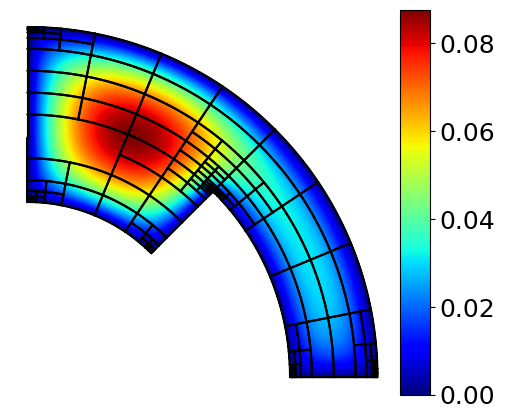

In [21]:
ax = MB.plot(uh, mesh=True, cbar_fontsize=18);
ax.axis('off');
plt.savefig('LshapeQ_solution.png' ,bbox_inches='tight', dpi=350);
plt.show()

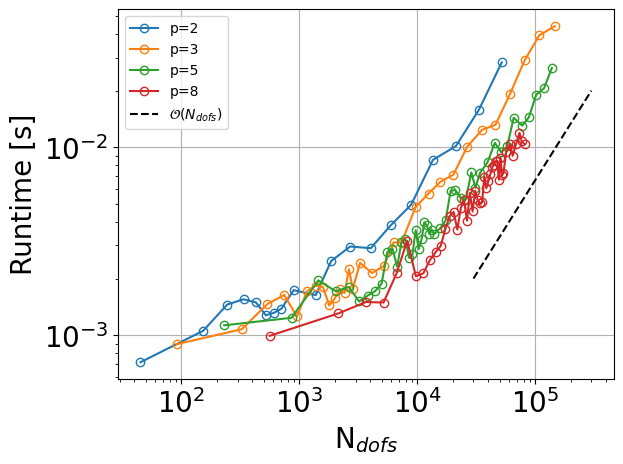

In [17]:
R2 = np.load('Lshape_adaptive_p2.npy')
R3 = np.load('Lshape_adaptive_p3.npy')
R5 = np.load('Lshape_adaptive_p5.npy')
R8 = np.load('Lshape_adaptive_p8.npy')

plt.loglog(R2[:,0], R2[:,6], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,6], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R5[:,0], R5[:,6], "o-", label="p=5",markerfacecolor='none')
plt.loglog(R8[:,0], R8[:,6], "o-", label="p=8",markerfacecolor='none')

# reference O(N) line
x = 3*1e4
y = 2*1e-3
l=1
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--",color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.savefig('Lshape_runtime_adaptive.pdf', bbox_inches='tight')

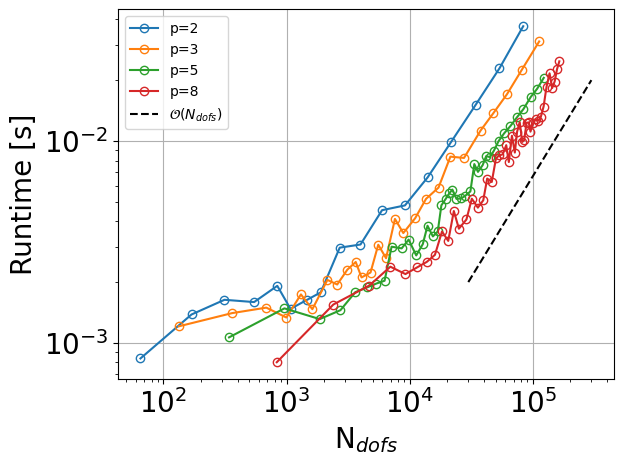

In [22]:
R2 = np.load('LshapeQ_adaptive_p2.npy')
R3 = np.load('LshapeQ_adaptive_p3.npy')
R5 = np.load('LshapeQ_adaptive_p5.npy')
R8 = np.load('LshapeQ_adaptive_p8.npy')

plt.loglog(R2[:-1,0], R2[:-1,6], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[:,0], R3[:,6], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R5[:,0], R5[:,6], "o-", label="p=5",markerfacecolor='none')
plt.loglog(R8[:,0], R8[:,6], "o-", label="p=8",markerfacecolor='none')

# reference O(N) line
x = 3*1e4
y = 2*1e-3
l=1
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--",color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend()
plt.grid(True)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.savefig('LshapeQ_runtime_adaptive.pdf', bbox_inches='tight')

In [13]:
R2

array([[6.50000e+01, 3.00000e+00, 0.00000e+00, 1.81772e-01, 0.00000e+00, 4.33445e-04, 8.37326e-04],
       [1.69000e+02, 9.00000e+00, 0.00000e+00, 9.89401e-02, 0.00000e+00, 8.35657e-04, 1.38235e-03],
       [3.13000e+02, 1.80000e+01, 0.00000e+00, 6.14843e-02, 0.00000e+00, 1.08933e-03, 1.63436e-03],
       [5.45000e+02, 3.30000e+01, 0.00000e+00, 4.07207e-02, 0.00000e+00, 1.01781e-03, 1.59240e-03],
       [8.41000e+02, 5.10000e+01, 0.00000e+00, 2.47956e-02, 0.00000e+00, 1.27506e-03, 1.91617e-03],
       [1.07700e+03, 6.60000e+01, 0.00000e+00, 1.67344e-02, 0.00000e+00, 1.01113e-03, 1.47367e-03],
       [1.46500e+03, 9.00000e+01, 0.00000e+00, 1.09356e-02, 0.00000e+00, 1.14274e-03, 1.63245e-03],
       [1.89700e+03, 1.17000e+02, 0.00000e+00, 7.10992e-03, 0.00000e+00, 1.27482e-03, 1.77908e-03],
       [2.70500e+03, 1.68000e+02, 0.00000e+00, 4.56452e-03, 0.00000e+00, 2.27594e-03, 2.96140e-03],
       [3.98900e+03, 2.49000e+02, 0.00000e+00, 2.92035e-03, 0.00000e+00, 2.47550e-03, 3.06964e-03],


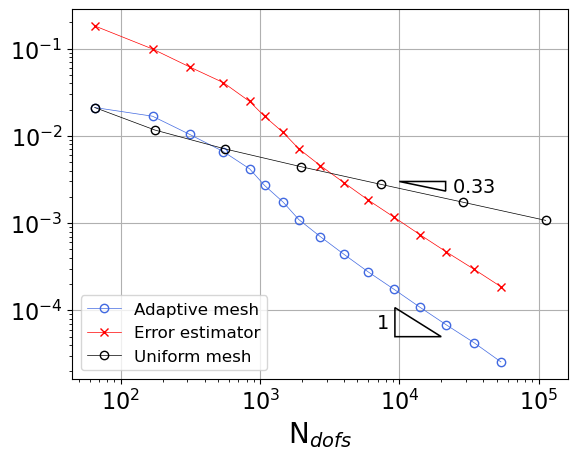

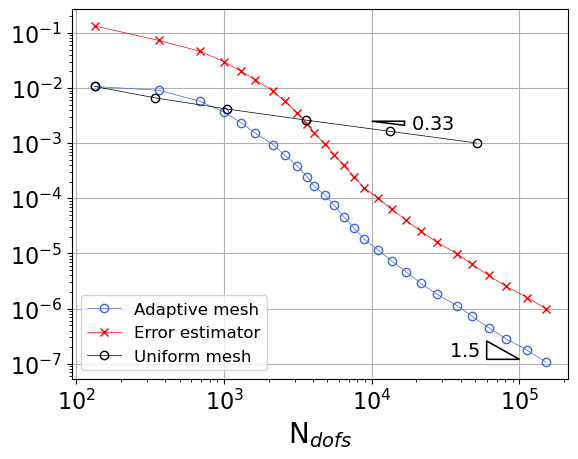

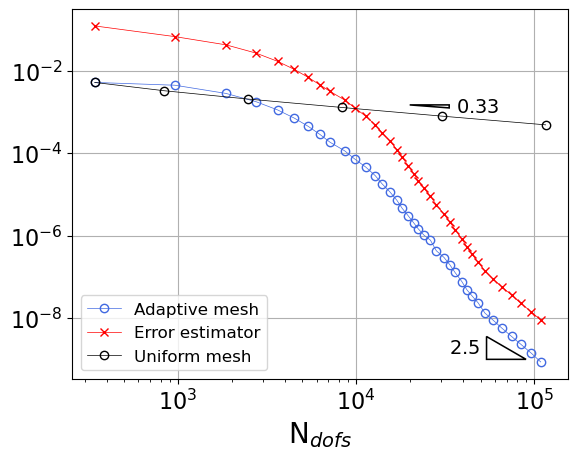

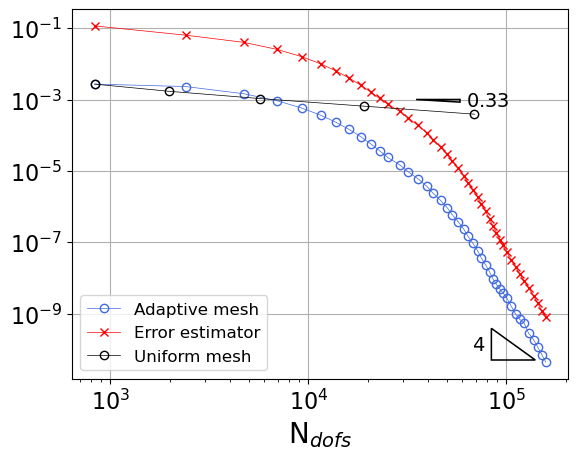

In [86]:
# R_a = np.load('LshapeQ_adaptive.npy')
# R_u = np.load('LshapeQ_uniform.npy')

# numdofs=R_u[:,0]
# numdofs_a = R_a[:,0]
# Eerr = R_u[:,2]
# Eerr_a = R_a[:,2]
pos=((2*1e4,5*1e-5),(1e5,1.2*1e-7),(9*1e4,1e-9),(1.4*1e5,5*1e-11))
pos_u=((1e4,3*1e-3),(1e4,2.5*1e-3),(2*1e4,1.5*1e-3),(3.5*1e4,1e-3))
w = (1.5,1,1,1)
inv = (True,True,True,True)
for i, deg in enumerate((2,3,5,8)):
    R_a = np.load('LshapeQ_adaptive_p'+str(deg)+'.npy')
    R_u = np.load('LshapeQ_uniform_p'+str(deg)+'.npy')
    numdofs=R_u[:,0]
    numdofs_a = R_a[:,0]
    Eerr = R_u[:,2]
    Eerr_a = R_a[:,2]
    Eta = R_a[:,3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('LQp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

[14.76398 14.86665 14.88206 14.87924 14.86917 14.8473  14.80056 14.71255 14.93218 14.77854 15.3237  15.25618 15.28794 15.39231 15.56772 15.57991 15.49228 15.77365 15.66619]


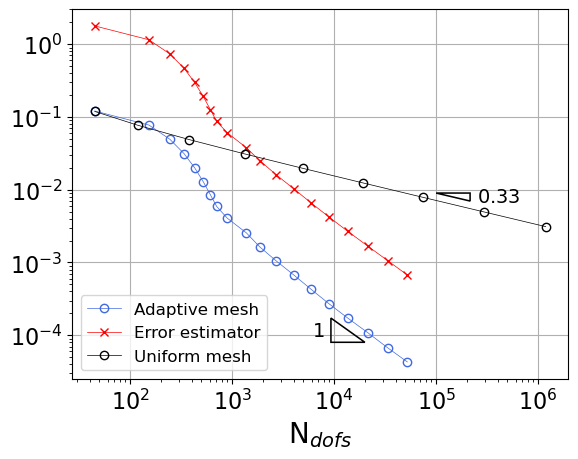

[22.74418 22.55771 22.43892 22.37329 22.33819 22.31787 22.30138 22.27738 22.22606 22.10344 21.81059 21.15132 19.85771 17.88069 17.08235 16.90659 18.37344 18.21514 17.41829 18.18532 17.67959 18.6301  18.61411 18.35945 18.32579 18.4472  18.66829 18.63146 18.42653 18.34919]


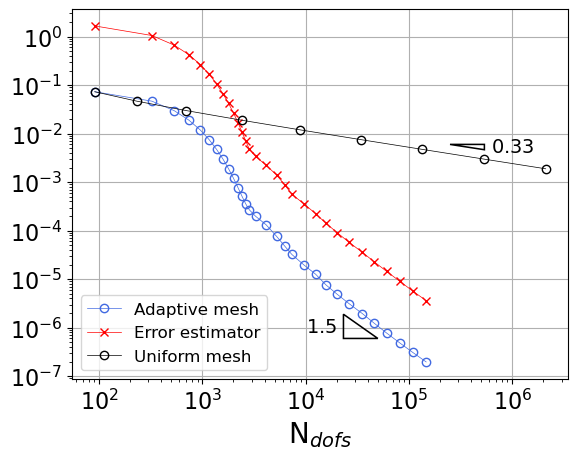

[40.43318 40.1438  39.99204 39.91569 39.8777  39.85881 39.8494  39.84469 39.84229 39.84097 39.84003 39.83882 39.83636 39.83046 39.81575 39.77883 39.68636 39.45649 38.89636 37.59475 34.86995 30.1871  24.18472 18.63695 16.90268 16.67451 17.87542 17.2051  18.66128 20.44223 20.77228 19.92517 18.57023 18.62024 18.25837 17.72139 17.80298 18.52399 17.93239 18.76765 18.74114 18.72557 18.34121]


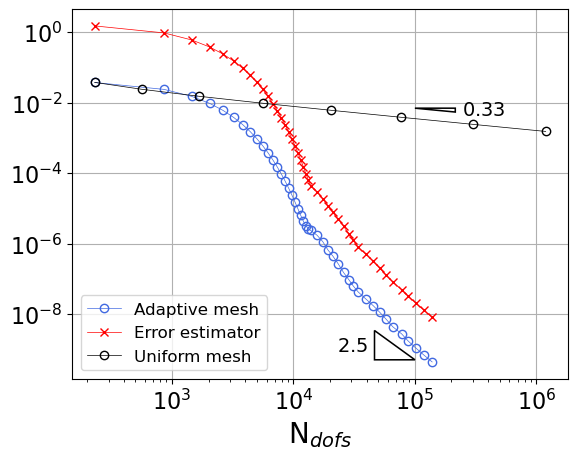

[71.03914 70.75417 70.61778 70.55286 70.52161 70.50635 70.49882 70.49509 70.49323 70.4923  70.49184 70.49161 70.49149 70.49143 70.4914  70.49139 70.49137 70.49136 70.49133 70.49125 70.49106 70.49057 70.48935 70.48629 70.47854 70.45903 70.40989 70.28676 69.97965 69.22376 67.42534 63.47203 56.04268 45.2386  33.69273 24.37221 20.15233 19.83289 17.6025  15.79885 20.1418  20.33869 24.03573]


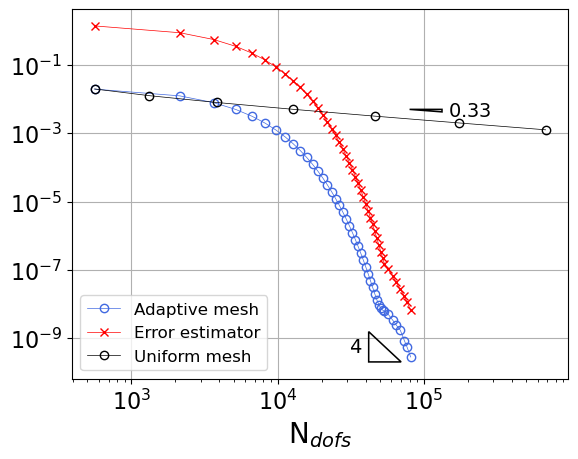

In [6]:
# R_a = np.load('Lshape_adaptive.npy')
# R_u = np.load('Lshape_uniform.npy')

# numdofs=R_u[:,0]
# numdofs_a = R[:,0]
# Eerr = R_u[:,2]
# Eerr_a = R[:,2]
pos=((2*1e4,8*1e-5),(5*1e4,6*1e-7),(1e5,5*1e-10),(7*1e4,2*1e-10))
pos_u=((1e5,9*1e-3),(2.5*1e5,6*1e-3),(1e5,7*1e-3),(8*1e4,5*1e-3))
w = (1.5,1.5,1.5,1)
inv = (True,True,True,True)
for i, deg in enumerate((2,3,5,8)):
    R_a = np.load('Lshape_adaptive_p'+str(deg)+'.npy')
    R_u = np.load('Lshape_uniform_p'+str(deg)+'.npy')
    numdofs=R_u[:,0]
    numdofs_a = R_a[:,0]
    Eerr = R_u[:,2]
    Eerr_a = R_a[:,2]
    Eta = R_a[:,3]

    numdofs=numdofs[numdofs!=0]
    numdofs_a=numdofs_a[numdofs_a != 0]
    Eerr_a = Eerr_a[Eerr_a!=0]
    Eerr = Eerr[Eerr!=0]
    Eta = Eta[Eta!=0]
    print(Eta/Eerr_a)
    
    fig, ax = plt.subplots()
    plt.loglog(numdofs_a, Eerr_a, 'o-',color='royalblue',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs_a, Eta, 'x-',color='red',linewidth=0.5, markerfacecolor='none')
    plt.loglog(numdofs, Eerr, 'o-',color='black',linewidth=0.5, markerfacecolor='none')
    plt.grid('True');
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(['Adaptive mesh','Error estimator','Uniform mesh'],loc='lower left',prop={'size': 12})
    plt.xlabel("N$_{dofs}$",size=20)
    draw_loglog_slope(fig,ax,pos[i],w[i],slope=int(deg/2) if deg%2==0 else deg/2,inverted=inv[i], color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)
    draw_loglog_slope(fig,ax,pos_u[i],w[i],0.33,inverted=False, color='black', polygon_kwargs=None, label=True, labelcolor=None, label_kwargs={'fontsize':14}, zorder=None)

    plt.savefig('Lp'+str(deg)+'n'+str(deg+1)+'H1_cnv.pdf', bbox_inches='tight')
    plt.show()
    

In [14]:
deg=2
M = Lshape(deg,deg+1)
MB = assemble.MultiBasis(M, subspace='C0')

maxiter=12
R=np.zeros((maxiter,3))
for i in range(maxiter):
    M.h_refine(-1);
    MB = assemble.MultiBasis(M)

    t=time.time()
    B=MB.set_constraints(subspace='C0')
    R[i,0] = MB.nLocDofs
    R[i,1] = time.time()-t

    I = np.unique(B.indices)
    F = np.setdiff1d(np.arange(MB.N_ofs[-1]),I)

    R_related = scipy.sparse.coo_matrix((np.ones(len(I)),(np.arange(len(I)),I)),shape=(len(I),MB.N_ofs[-1]))
    R_free = scipy.sparse.coo_matrix((np.ones(len(F)),(np.arange(len(F)),F)),shape=(len(F),MB.N_ofs[-1]))
    
    B = (MB.B@R_related.T).tocsr()
    t1 =time.time()
    Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
    Basis = scipy.sparse.hstack([R_free.T, R_related.T@Basis], format='csc')
    R[i,2]=time.time()-t1

np.save('Lshape_runtime_uniform_p'+str(deg),R)

setting up constraints took 0.0008604526519775391 seconds.
Basis setup took 0.0011444091796875 seconds
setting up constraints took 0.0008759498596191406 seconds.
setting up constraints took 0.0013275146484375 seconds.
setting up constraints took 0.0008475780487060547 seconds.
setting up constraints took 0.001322031021118164 seconds.
setting up constraints took 0.0012385845184326172 seconds.
setting up constraints took 0.0020303726196289062 seconds.
setting up constraints took 0.004973173141479492 seconds.
setting up constraints took 0.016063213348388672 seconds.
setting up constraints took 0.06496357917785645 seconds.
setting up constraints took 0.5259149074554443 seconds.
setting up constraints took 1.9996404647827148 seconds.
setting up constraints took 8.235486268997192 seconds.


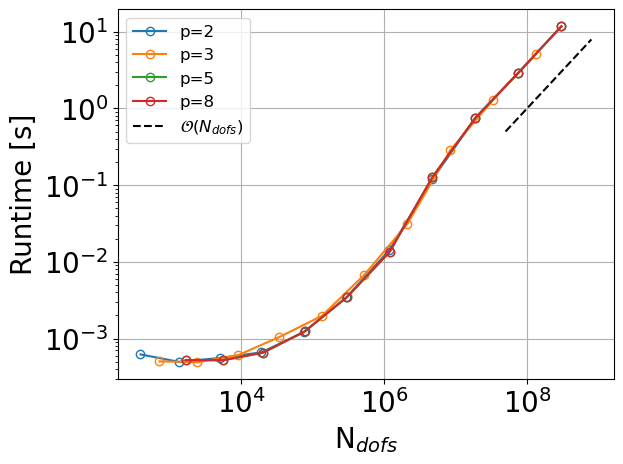

In [15]:
R2 = np.load('Lshape_runtime_uniform_p2.npy')
R3 = np.load('Lshape_runtime_uniform_p3.npy')
R5 = np.load('Lshape_runtime_uniform_p5.npy')
R8 = np.load('Lshape_runtime_uniform_p5.npy')

plt.loglog(R2[1:,0], R2[1:,2], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[1:,0], R3[1:,2], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R5[1:,0], R5[1:,2], "o-", label="p=5",markerfacecolor='none')
plt.loglog(R8[1:,0], R8[1:,2], "o-", label="p=8",markerfacecolor='none')

# reference O(N) line
x = 5*1e7
y = 5*1e-1
l=1.2
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--", color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend(loc='upper left',prop={'size': 12})
plt.grid(True)
plt.savefig('Lshape_runtime_uniform.pdf', bbox_inches='tight')

In [12]:
deg=2
M = LshapeAnnulus(deg,deg+1)
MB = assemble.MultiBasis(M, subspace='C0')

maxiter=11
R=np.zeros((maxiter,3))
for i in range(maxiter):
    M.h_refine(-1);
    MB = assemble.MultiBasis(M)

    t=time.time()
    B=MB.set_constraints(subspace='C0')
    R[i,0] = MB.nLocDofs
    R[i,1] = time.time()-t

    I = np.unique(B.indices)
    F = np.setdiff1d(np.arange(MB.N_ofs[-1]),I)

    R_related = scipy.sparse.coo_matrix((np.ones(len(I)),(np.arange(len(I)),I)),shape=(len(I),MB.N_ofs[-1]))
    R_free = scipy.sparse.coo_matrix((np.ones(len(F)),(np.arange(len(F)),F)),shape=(len(F),MB.N_ofs[-1]))
    
    B = (MB.B@R_related.T).tocsr()
    t1 =time.time()
    Basis, _ = algebra_cy.pyx_compute_basis(B.shape[0], B.shape[1], B, maxiter=100, switch=0)
    Basis = scipy.sparse.hstack([R_free.T, R_related.T@Basis], format='csc')
    R[i,2]=time.time()-t1

np.save('LshapeQ_runtime_uniform_p'+str(deg),R)

setting up constraints took 0.0015323162078857422 seconds.
Basis setup took 0.0010132789611816406 seconds
setting up constraints took 0.001474618911743164 seconds.
setting up constraints took 0.002526998519897461 seconds.
setting up constraints took 0.001811981201171875 seconds.
setting up constraints took 0.002023458480834961 seconds.
setting up constraints took 0.002344846725463867 seconds.
setting up constraints took 0.0040934085845947266 seconds.
setting up constraints took 0.010106325149536133 seconds.
setting up constraints took 0.03243827819824219 seconds.
setting up constraints took 0.14985108375549316 seconds.
setting up constraints took 1.0736019611358643 seconds.
setting up constraints took 4.04949426651001 seconds.


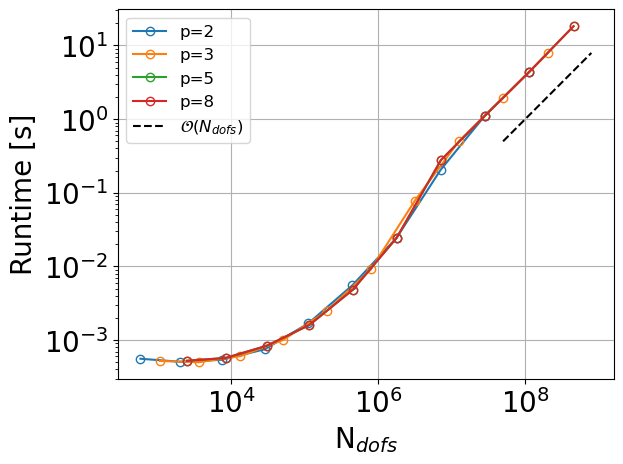

In [13]:
R2 = np.load('LshapeQ_runtime_uniform_p2.npy')
R3 = np.load('LshapeQ_runtime_uniform_p3.npy')
R5 = np.load('LshapeQ_runtime_uniform_p5.npy')
R8 = np.load('LshapeQ_runtime_uniform_p5.npy')

plt.loglog(R2[1:,0], R2[1:,2], "o-", label="p=2",markerfacecolor='none')
plt.loglog(R3[1:,0], R3[1:,2], "o-", label="p=3",markerfacecolor='none')
plt.loglog(R5[1:,0], R5[1:,2], "o-", label="p=5",markerfacecolor='none')
plt.loglog(R8[1:,0], R8[1:,2], "o-", label="p=8",markerfacecolor='none')

# reference O(N) line
x = 5*1e7
y = 5*1e-1
l=1.2
plt.loglog(np.array([x,10**(l)*x]), (y/x)*np.array([x,10**(l)*x]), "--", color='black', label=r"$\mathcal{O}(N_{dofs})$")

plt.tick_params(axis='both', labelsize=20)
plt.ylabel("Runtime [s]", size=20)
plt.xlabel("N$_{dofs}$",size=20)
plt.legend(loc='upper left',prop={'size': 12})
plt.grid(True)
plt.savefig('LshapeQ_runtime_uniform.pdf', bbox_inches='tight')

In [49]:
Eta/Eerr_a

array([7.76002, 8.24941, 8.52209, 8.66644, 8.74082, 8.77859, 8.79762, 8.80718, 8.81197, 8.81436, 8.81556, 8.81616, 8.81646, 8.81661, 8.81669, 8.81673, 8.81674, 8.81675, 8.81676, 8.81676, 8.81676, 8.81675, 8.81672, 8.81666, 8.8165 , 8.8161 , 8.81509, 8.81257, 8.80637, 8.79108, 8.75506, 8.67912, 8.54504, 8.45668, 8.4702 , 8.16948])